In [1]:
import pandas as pd
import numpy as np
import hashlib
import time

print("Starting the data processing...")

# Function to load a CSV file given its file path
def load_file(file_path):
    return pd.read_csv(file_path)

# File paths and file names
base_path = "/home/uottawa.o.univ/hpate033/GAN Project/CIC-DDoS2019/"
files = [
    "DrDoS_LDAP.csv", "DrDoS_MSSQL.csv", "DrDoS_NetBIOS.csv",
    "DrDoS_NTP.csv", "DrDoS_SNMP.csv", "DrDoS_SSDP.csv",
    "DrDoS_UDP.csv", "DrDoS_DNS.csv"
]

print(f"Total files to process: {len(files)}")

# List to store balanced samples from each file
balanced_dfs = []

for i, file in enumerate(files, 1):
    print(f"\nProcessing file {i} of {len(files)}: {file}")
    start_time = time.time()
    
    file_path = base_path + file
    try:
        df = load_file(file_path)
        print(f"  {file} loaded successfully!")
    except FileNotFoundError:
        print(f"  Error: {file_path} not found!")
        continue
    
    print("  Cleaning and preprocessing data...")
    # Replace infinite values
    df = df.replace(['Infinity', np.inf], 0)
    
    # Convert numerical columns safely
    df[' Flow Packets/s'] = pd.to_numeric(df[' Flow Packets/s'], errors='coerce').fillna(0)
    df['Flow Bytes/s'] = pd.to_numeric(df['Flow Bytes/s'], errors='coerce').fillna(0)
    
    # Convert labels to numeric
    df[' Label'] = df[' Label'].replace({
        'BENIGN': 0, 
        'DrDoS_DNS': 1, 'DrDoS_LDAP': 1, 'DrDoS_MSSQL': 1,
        'DrDoS_NTP': 1, 'DrDoS_NetBIOS': 1, 'DrDoS_SNMP': 1, 'DrDoS_SSDP': 1,
        'DrDoS_UDP': 1
    }).astype(int)
    
    # Drop unnecessary columns
    df.drop(columns=[' Timestamp', ' Source IP', ' Destination IP', 'Flow ID', 'SimillarHTTP', 'Unnamed: 0'], inplace=True)
    
    # Remove extra spaces in column names
    df.columns = df.columns.str.strip()
    
    print("  Sampling data...")
    # Sample 100000 benign and 100000 DrDoS (attack) samples
    benign_df = df[df['Label'] == 0]
    attack_df = df[df['Label'] == 1]
    
    if len(benign_df) < 100000:
        print(f"  Warning: {file} has only {len(benign_df)} benign samples.")
        benign_sample = benign_df
    else:
        benign_sample = benign_df.sample(n=100000, random_state=42)
    
    if len(attack_df) < 100000:
        print(f"  Warning: {file} has only {len(attack_df)} DrDoS samples.")
        attack_sample = attack_df
    else:
        attack_sample = attack_df.sample(n=100000, random_state=42)
    
    balanced_sample = pd.concat([benign_sample, attack_sample], ignore_index=True)
    balanced_dfs.append(balanced_sample)
    print(f"  {file}: Selected {len(benign_sample)} benign and {len(attack_sample)} DrDoS samples.")
    
    end_time = time.time()
    print(f"  Time taken to process {file}: {end_time - start_time:.2f} seconds")

print("\nCombining all balanced samples...")
# Combine balanced samples from all files into one benchmarking dataframe
benchmark_df = pd.concat(balanced_dfs, ignore_index=True)
print("Benchmark dataframe created successfully!")

print("\nFinal benchmark dataframe info:")
benchmark_df.info()

print("\nProcessing complete!")

# A helper function that converts a string into a numeric hash (if needed later)
def string2numeric_hash(text):
    return int(hashlib.md5(text.encode()).hexdigest()[:8], 16)


Starting the data processing...
Total files to process: 8

Processing file 1 of 8: DrDoS_LDAP.csv


/tmp/ipykernel_837763/290030618.py:31: DtypeWarning: Columns (85) have mixed types.Specify dtype option on import or set low_memory=False.
  df = load_file(file_path)


  DrDoS_LDAP.csv loaded successfully!
  Cleaning and preprocessing data...
  Sampling data...
  DrDoS_LDAP.csv: Selected 1612 benign and 100000 DrDoS samples.
  Time taken to process DrDoS_LDAP.csv: 14.50 seconds

Processing file 2 of 8: DrDoS_MSSQL.csv
  DrDoS_MSSQL.csv loaded successfully!
  Cleaning and preprocessing data...
  Sampling data...
  DrDoS_MSSQL.csv: Selected 2006 benign and 100000 DrDoS samples.
  Time taken to process DrDoS_MSSQL.csv: 30.26 seconds

Processing file 3 of 8: DrDoS_NetBIOS.csv
  DrDoS_NetBIOS.csv loaded successfully!
  Cleaning and preprocessing data...
  Sampling data...
  DrDoS_NetBIOS.csv: Selected 1707 benign and 100000 DrDoS samples.
  Time taken to process DrDoS_NetBIOS.csv: 26.32 seconds

Processing file 4 of 8: DrDoS_NTP.csv
  DrDoS_NTP.csv loaded successfully!
  Cleaning and preprocessing data...
  Sampling data...
  DrDoS_NTP.csv: Selected 14365 benign and 100000 DrDoS samples.
  Time taken to process DrDoS_NTP.csv: 8.85 seconds

Processing file

Starting DDoS detection feature selection experiment...
Loading dataset...
Dataset loaded: 827519 samples with 81 features
Splitting data into training and test sets...
Training set: 579263 samples, Test set: 248256 samples
Standardizing features...
Feature standardization complete
Defining top features based on sensitivity ranking and synergistic pairs...
Sensitivity-ranked features: 71 features
First 5 features: ['Inbound', 'Protocol', 'URG Flag Count', 'Down/Up Ratio', 'ACK Flag Count']
Last 5 features: ['Flow Packets/s', 'Flow IAT Std', 'Fwd IAT Std', 'Bwd Avg Bulk Rate', 'Bwd Avg Packets/Bulk']
Creating GAN feature set...
GAN feature set created with 71 features
Initializing machine learning models...
Initialized 2 models: Logistic Regression, Random Forest
Applying Chi-Square feature selection with 71 features...
Applying ANOVA feature selection with 71 features...


/usr/lib/python3/dist-packages/sklearn/feature_selection/_univariate_selection.py:114: UserWarning: Features [33 34 35 45 48 52 58 59 60 61 62 63] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx,
/usr/lib/python3/dist-packages/sklearn/feature_selection/_univariate_selection.py:116: RuntimeWarning: invalid value encountered in true_divide
  f = msb / msw


Applying Mutual Information feature selection with 71 features...
Feature selection outputs stored for Chi-Square, ANOVA, and Mutual Information.
Starting evaluation with feature counts: [10, 20, 30, 40, 50, 60, 70]

Processing with 10 features...
  Using top 10 features from Chi-Square...
    Training Logistic Regression...
    Logistic Regression training completed in 0.4087 seconds
    Logistic Regression evaluation complete
    Training Random Forest...
    Random Forest training completed in 5.2494 seconds
    Random Forest evaluation complete
  Using top 10 features from ANOVA...
    Training Logistic Regression...
    Logistic Regression training completed in 0.4026 seconds
    Logistic Regression evaluation complete
    Training Random Forest...
    Random Forest training completed in 5.2728 seconds
    Random Forest evaluation complete
  Using top 10 features from Mutual Information...
    Training Logistic Regression...
    Logistic Regression training completed in 1.9787 sec

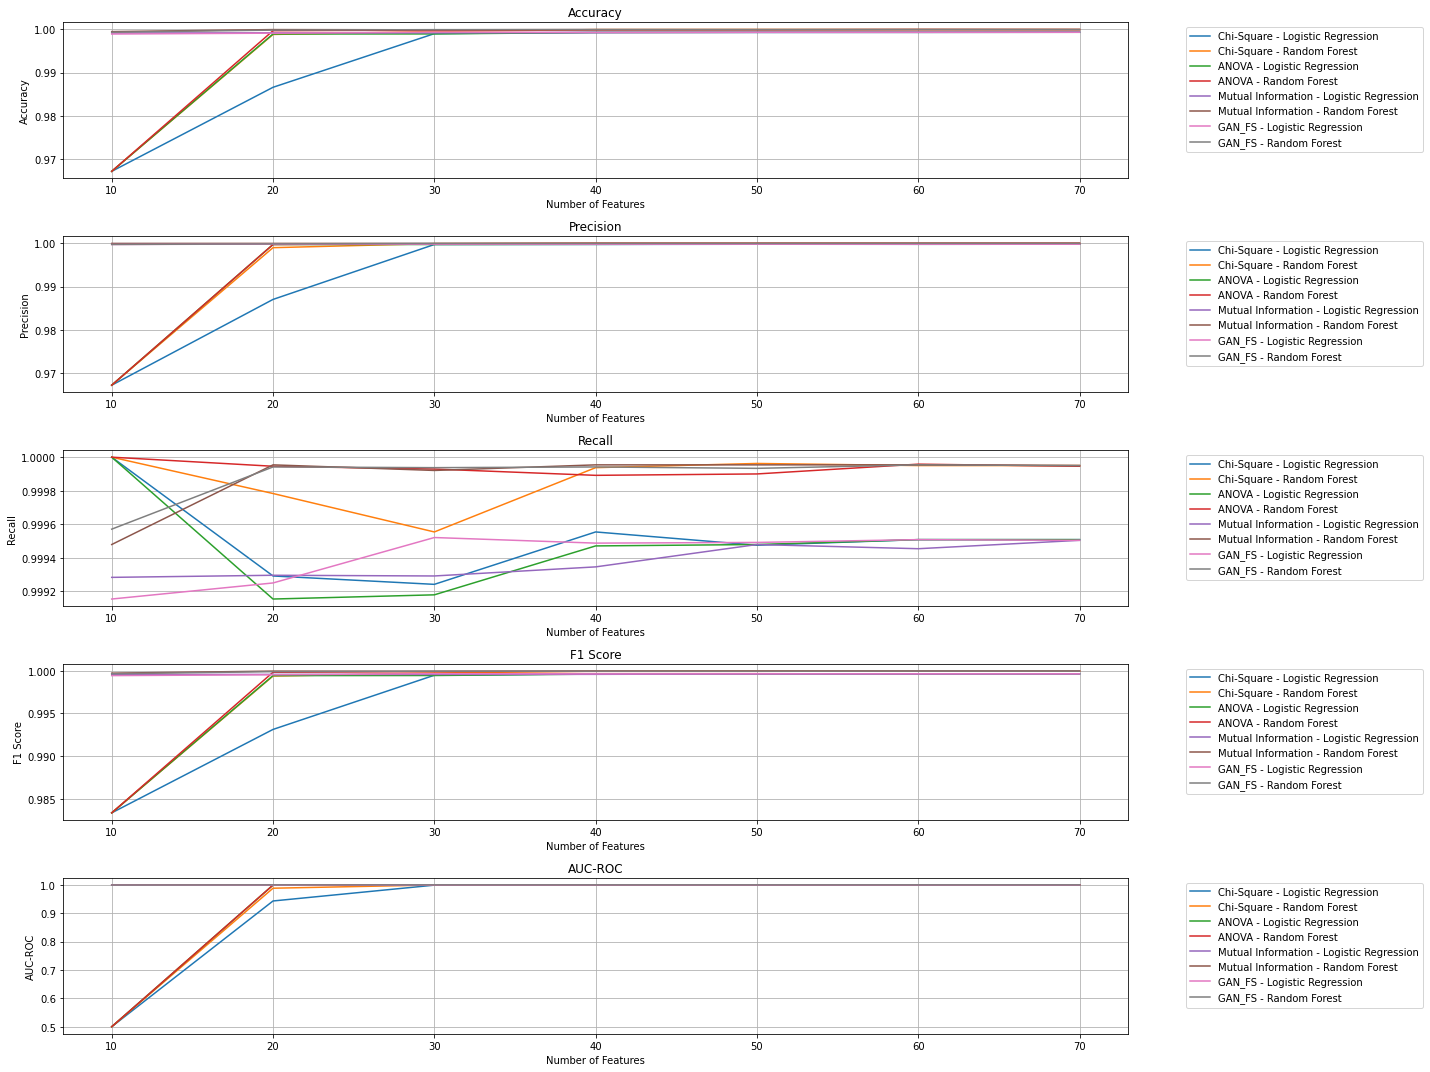

Creating individual model performance plots...
  Generating plot for Logistic Regression...
  Displaying plot for Logistic Regression...


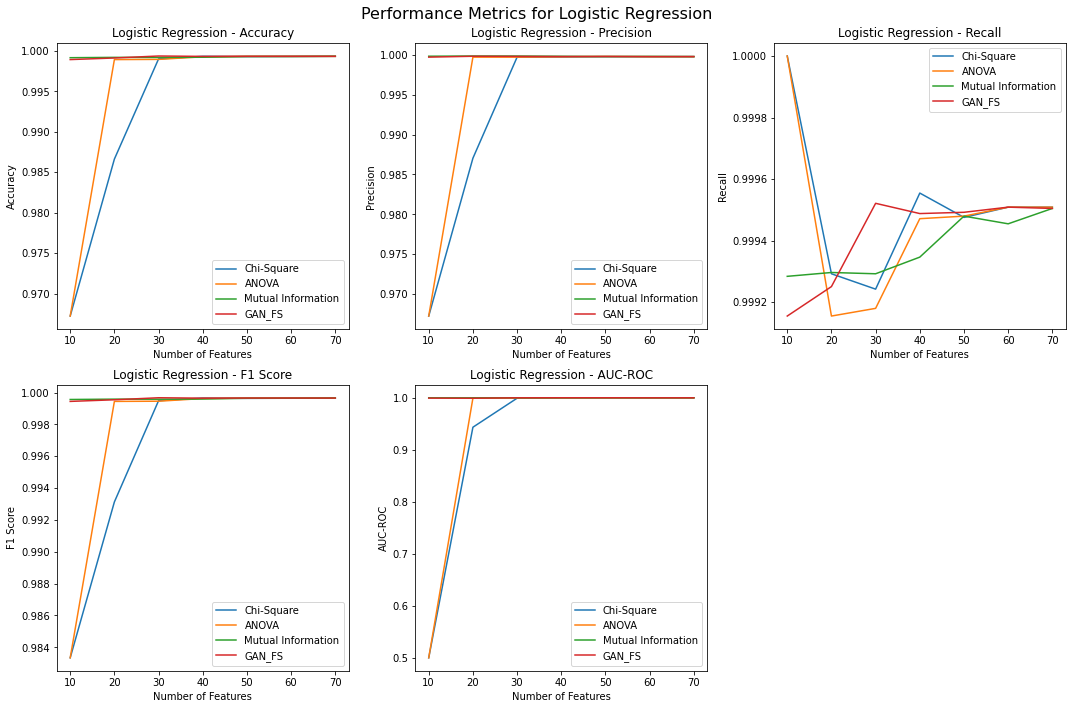

  Generating plot for Random Forest...
  Displaying plot for Random Forest...


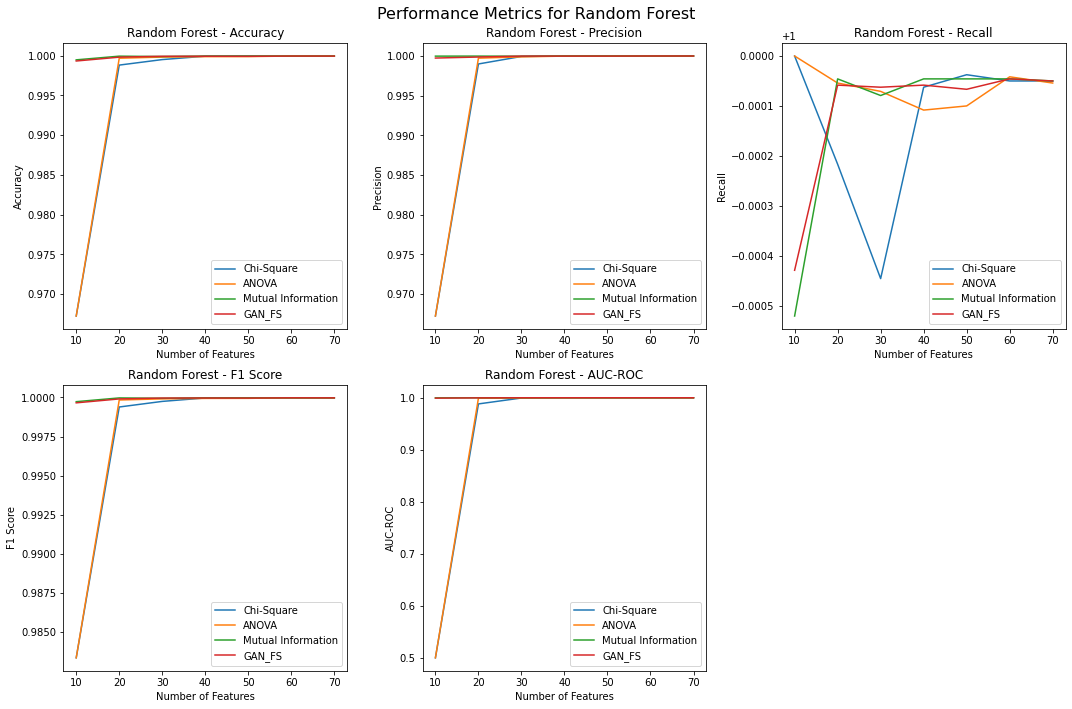

Creating training time comparison plot...
Displaying training time comparison plot...


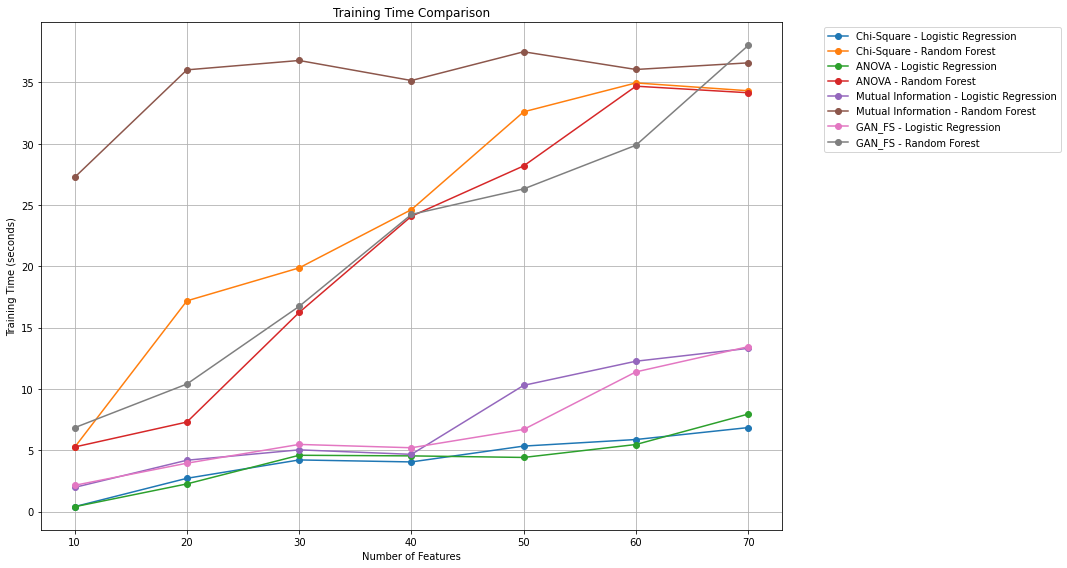

Creating model-specific training time plots...
  Displaying training time plot for Logistic Regression...


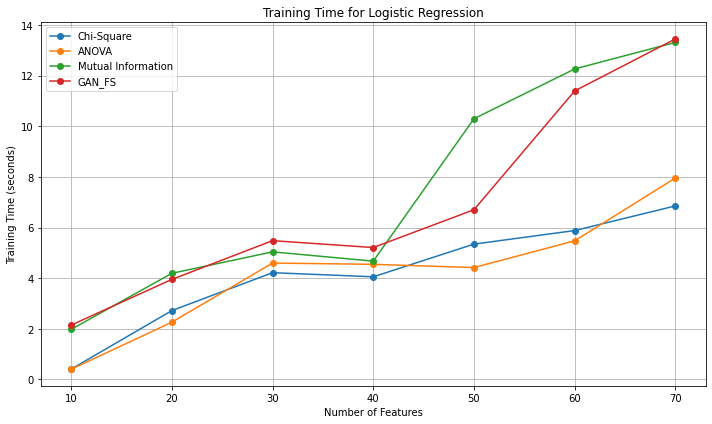

  Displaying training time plot for Random Forest...


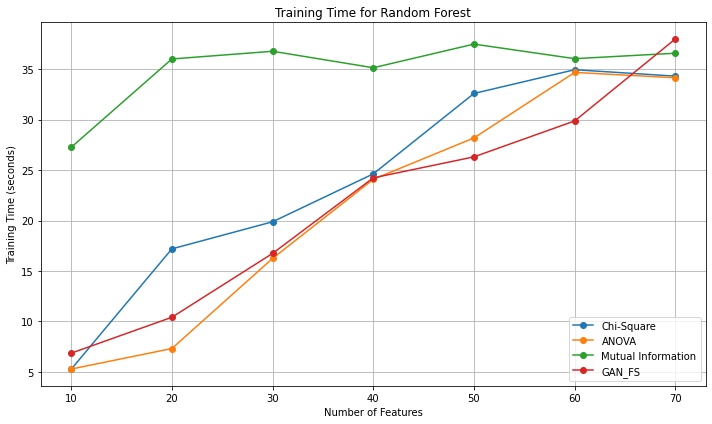

Experiment completed successfully!
{'Accuracy': {'Chi-Square': {'Logistic Regression': [0.967231406290281, 0.986626707914411, 0.9990050592936324, 0.999323279195669, 0.9992910543954627, 0.9993071667955659, 0.9993273072956947], 'Random Forest': [0.967231406290281, 0.9988197666924465, 0.9995125998968807, 0.9999395784996133, 0.999963747099768, 0.9999516627996906, 0.9999516627996906]}, 'ANOVA': {'Logistic Regression': [0.967231406290281, 0.998920469193091, 0.9989446377932457, 0.9992668857953081, 0.9993192510956432, 0.9993152229956175, 0.999323279195669], 'Random Forest': [0.967231406290281, 0.9996858081979891, 0.9998267916988914, 0.9998831850992523, 0.999891241299304, 0.9999597189997422, 0.9999476346996649]}, 'Mutual Information': {'Logistic Regression': [0.9991540989945862, 0.9991943799948441, 0.9991863237947924, 0.9992104923949472, 0.9992991105955144, 0.9993031386955401, 0.999323279195669], 'Random Forest': [0.9994803750966744, 0.9999436065996391, 0.9998952693993297, 0.9999556908997165, 0

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import time

print("Starting DDoS detection feature selection experiment...")

# Load dataset 
print("Loading dataset...")
X = benchmark_df.drop('Label', axis=1)
y = benchmark_df['Label']
print(f"Dataset loaded: {X.shape[0]} samples with {X.shape[1]} features")

# Split data
print("Splitting data into training and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

# Standardize features
print("Standardizing features...")
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Feature standardization complete")

print("Defining top features based on sensitivity ranking from GANFS Algorithm...")
# Define top features (Sensitivity Ranking) from GANFS Algorithm
top_features_sensitivity = [
    'Inbound', 'Protocol', 'URG Flag Count', 'Down/Up Ratio', 'ACK Flag Count',
    'Fwd PSH Flags', 'RST Flag Count', 'Bwd Packet Length Min', 'CWE Flag Count',
    'SYN Flag Count', 'Bwd IAT Min', 'Subflow Bwd Bytes', 'Bwd Packet Length Max',
    'Init_Win_bytes_backward', 'Bwd Header Length', 'act_data_pkt_fwd',
    'Total Length of Bwd Packets', 'Active Std', 'Active Min', 'Init_Win_bytes_forward',
    'Total Backward Packets', 'Subflow Bwd Packets', 'Fwd Packet Length Min',
    'Fwd Packet Length Max', 'Avg Bwd Segment Size', 'Bwd Packet Length Std',
    'Active Mean', 'Fwd IAT Min', 'Max Packet Length', 'Active Max',
    'Subflow Fwd Bytes', 'Subflow Fwd Packets', 'Bwd Packet Length Mean',
    'Average Packet Size', 'Idle Std', 'Total Fwd Packets', 'Avg Fwd Segment Size',
    'Fwd Packet Length Mean', 'Min Packet Length', 'Total Length of Fwd Packets',
    'Flow IAT Min', 'Fwd Packet Length Std', 'Packet Length Mean', 'Packet Length Variance',
    'Bwd IAT Mean', 'Bwd IAT Max', 'min_seg_size_forward', 'Bwd IAT Total', 'Idle Min',
    'Idle Mean', 'Bwd Packets/s', 'Packet Length Std', 'Bwd IAT Std', 'Idle Max',
    'Fwd Header Length.1', 'Fwd Header Length', 'Source Port', 'Destination Port',
    'Flow IAT Max', 'Fwd IAT Max', 'Flow Duration', 'Fwd IAT Total', 'Fwd IAT Mean',
    'Flow Bytes/s', 'Flow IAT Mean', 'Fwd Packets/s', 'Flow Packets/s', 'Flow IAT Std',
    'Fwd IAT Std', 'Bwd Avg Bulk Rate', 'Bwd Avg Packets/Bulk'
]

print(f"Sensitivity-ranked features: {len(top_features_sensitivity)} features")
print("First 5 features:", top_features_sensitivity[:5])
print("Last 5 features:", top_features_sensitivity[-5:])

# Combine individual and pairwise features into a new feature set
print("Creating GAN feature set...")
GAN_features = list(top_features_sensitivity)
print(f"GAN feature set created with {len(GAN_features)} features")

# Initialize models
print("Initializing machine learning models...")
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier()
}
print(f"Initialized {len(models)} models: {', '.join(models.keys())}")

# Initialize feature selection techniques
def get_best_features_selector(method, k_features):
    if method == 'Chi-Square':
        return SelectKBest(score_func=chi2, k=k_features)
    elif method == 'ANOVA':
        return SelectKBest(score_func=f_classif, k=k_features)
    elif method == 'Mutual Information':
        return SelectKBest(score_func=mutual_info_classif, k=k_features)

# Initialize results structure
results = {
    metric: {
        method: {
            model_name: [] for model_name in models.keys()
        } for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']
    } for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
}

# Initialize training times structure
training_times = {
    method: {
        model_name: [] for model_name in models.keys()
    } for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']
}

# Apply feature selection once with max features
max_features = 71
fs_outputs = {}
for fs_method in ['Chi-Square', 'ANOVA', 'Mutual Information']:
    print(f"Applying {fs_method} feature selection with {max_features} features...")
    fs = get_best_features_selector(fs_method, max_features)
    fs.fit(X_train, y_train)
    fs_outputs[fs_method] = fs

print("Feature selection outputs stored for Chi-Square, ANOVA, and Mutual Information.")

# Iterate over number of features to select
feature_counts = range(10, 71, 10)
print(f"Starting evaluation with feature counts: {list(feature_counts)}")

for k in feature_counts:
    print(f"\nProcessing with {k} features...")
    
    # For traditional feature selection methods
    for fs_method in ['Chi-Square', 'ANOVA', 'Mutual Information']:
        print(f"  Using top {k} features from {fs_method}...")
        
        # Get the indices of the top k features
        top_k_indices = fs_outputs[fs_method].scores_.argsort()[-k:][::-1]
        
        # Select the top k features
        X_train_fs = X_train[:, top_k_indices]
        X_test_fs = X_test[:, top_k_indices]
        
        for model_name, model in models.items():
            print(f"    Training {model_name}...")
            
            # Measure training time
            start_time = time.time()
            model.fit(X_train_fs, y_train)
            end_time = time.time()
            training_time = end_time - start_time
            
            # Store the training time
            training_times[fs_method][model_name].append(training_time)
            print(f"    {model_name} training completed in {training_time:.4f} seconds")
            
            y_pred = model.predict(X_test_fs)
            y_prob = model.predict_proba(X_test_fs)[:, 1]

            # Store results directly for this model
            results['Accuracy'][fs_method][model_name].append(accuracy_score(y_test, y_pred))
            results['Precision'][fs_method][model_name].append(precision_score(y_test, y_pred))
            results['Recall'][fs_method][model_name].append(recall_score(y_test, y_pred))
            results['F1 Score'][fs_method][model_name].append(f1_score(y_test, y_pred))
            results['AUC-ROC'][fs_method][model_name].append(roc_auc_score(y_test, y_prob))
            print(f"    {model_name} evaluation complete")
    
    # For GAN feature set
    print(f"  Applying GAN feature selection...")
    X_train_GAN = X_train[:, [X.columns.get_loc(f) for f in GAN_features[:k]]]
    X_test_GAN = X_test[:, [X.columns.get_loc(f) for f in GAN_features[:k]]]

    for model_name, model in models.items():
        print(f"    Training {model_name} with GAN features...")
        
        # Measure training time
        start_time = time.time()
        model.fit(X_train_GAN, y_train)
        end_time = time.time()
        training_time = end_time - start_time
        
        # Store the training time
        training_times['GAN_FS'][model_name].append(training_time)
        print(f"    {model_name} training completed in {training_time:.4f} seconds")
        
        y_pred = model.predict(X_test_GAN)
        y_prob = model.predict_proba(X_test_GAN)[:, 1]

        # Store results directly for this model
        results['Accuracy']['GAN_FS'][model_name].append(accuracy_score(y_test, y_pred))
        results['Precision']['GAN_FS'][model_name].append(precision_score(y_test, y_pred))
        results['Recall']['GAN_FS'][model_name].append(recall_score(y_test, y_pred))
        results['F1 Score']['GAN_FS'][model_name].append(f1_score(y_test, y_pred))
        results['AUC-ROC']['GAN_FS'][model_name].append(roc_auc_score(y_test, y_prob))
        print(f"    {model_name} evaluation complete")
    
    print(f"Completed evaluation with {k} features")

print("All feature selection evaluations complete. Generating plots...")

# Plotting the performance results
print("Creating overall performance comparison plot...")
plt.figure(figsize=(20, 15))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']

for idx, metric in enumerate(metrics, 1):
    plt.subplot(len(metrics), 1, idx)
    
    for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
        for model_name in models.keys():
            plt.plot(
                feature_counts, 
                results[metric][method][model_name], 
                label=f"{method} - {model_name}"
            )
    
    plt.title(metric)
    plt.xlabel('Number of Features')
    plt.ylabel(metric)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(feature_counts)
    plt.grid(True)

plt.tight_layout()
print("Displaying overall performance comparison plot...")
plt.show()

# One figure per model for performance metrics
print("Creating individual model performance plots...")
for model_name in models.keys():
    print(f"  Generating plot for {model_name}...")
    plt.figure(figsize=(15, 10))
    
    for idx, metric in enumerate(metrics, 1):
        plt.subplot(2, 3, idx)
        
        for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
            plt.plot(
                feature_counts, 
                results[metric][method][model_name], 
                label=method
            )
        
        plt.title(f"{model_name} - {metric}")
        plt.xlabel('Number of Features')
        plt.ylabel(metric)
        plt.legend()
        plt.xticks(feature_counts)
    
    plt.tight_layout()
    plt.suptitle(f"Performance Metrics for {model_name}", fontsize=16)
    plt.subplots_adjust(top=0.93)
    print(f"  Displaying plot for {model_name}...")
    plt.show()

# Add plot for training times - overall comparison
print("Creating training time comparison plot...")
plt.figure(figsize=(15, 8))

for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
    for model_name in models.keys():
        plt.plot(
            feature_counts, 
            training_times[method][model_name], 
            label=f"{method} - {model_name}",
            marker='o'
        )

plt.title("Training Time Comparison")
plt.xlabel('Number of Features')
plt.ylabel('Training Time (seconds)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(feature_counts)
plt.grid(True)
plt.tight_layout()
print("Displaying training time comparison plot...")
plt.show()

# Plot training time for each model separately
print("Creating model-specific training time plots...")
for model_name in models.keys():
    plt.figure(figsize=(10, 6))
    
    for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
        plt.plot(
            feature_counts, 
            training_times[method][model_name], 
            label=method,
            marker='o'
        )
    
    plt.title(f"Training Time for {model_name}")
    plt.xlabel('Number of Features')
    plt.ylabel('Training Time (seconds)')
    plt.legend()
    plt.xticks(feature_counts)
    plt.grid(True)
    plt.tight_layout()
    print(f"  Displaying training time plot for {model_name}...")
    plt.show()

print("Experiment completed successfully!")
print(results)